# **Sparse Coding de Espectrogramas STFT — FSCC**
### Aprendizaje de Átomos Espectrales para Dígitos Hablados

## **Introducción**

El objetivo de este cuaderno es aprender una representación dispersa de dígitos hablados del dataset **FSCC (Free Spoken Connected Digits)** usando sparse coding sobre espectrogramas STFT.

La idea central: en lugar de trabajar con la señal de audio directamente, convertimos cada audio en un espectograma (una matriz tiempo-frecuencia) y aprendemos un diccionario de átomos espectrales capaz de reconstruir cualquier frame combinando unos pocos átomos con coeficientes dispersos.



### **(1) Cargamos las librerías y fijamos los parámetros globales**

In [2]:
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import os
import glob
import pandas as pd
import IPython.display as ipd

from sklearn.decomposition import MiniBatchDictionaryLearning, SparseCoder

np.random.seed(42)

# Parámetros globales
# FSCC usa audios de voz grabados a 16 kHz
SR           = 16000
N_FFT        = 512        # ventana de 32 ms a 16 kHz
HOP_LENGTH   = 128        # salto de 8 ms
MAX_DURATION = 3.0        # dígitos cortos, 3 s es suficiente
N_COMPONENTS = 512        # diccionario sobrecompleto (F=257 bins)
BATCH_SIZE   = 1024
ALPHA        = 0.5        # regularización L1
MAX_ITER     = 50
THRESHOLD    = 1e-3
DATASET_DIR = "datasets/free-spoken-digit-dataset/recordings"
print("Librerías cargadas.")


Librerías cargadas.


### **(2) Cargamos los archivos .wav del dataset FSCC y los almacenamos en un DataFrame**

In [3]:
def load_fscc(dataset_dir, sr=SR, max_dur=MAX_DURATION, max_files=2000):
    """
    Carga el dataset FSCC.
    Estructura esperada: dataset_dir/<digito>/<archivo>.wav
    donde <digito> es 0-9. También acepta estructura plana con
    archivos nombrados como <digito>_<speaker>_<idx>.wav.
    """
    # Buscar archivos en subdirectorios por dígito
    paths = []
    labels = []

    for digit in range(10):
        digit_dir = os.path.join(dataset_dir, str(digit))
        if os.path.isdir(digit_dir):
            wavs = sorted(glob.glob(os.path.join(digit_dir, "*.wav")))
            paths.extend(wavs)
            labels.extend([digit] * len(wavs))

    # Si no hay subdirectorios, intentar estructura plana
    if len(paths) == 0:
        all_wavs = sorted(glob.glob(os.path.join(dataset_dir, "**", "*.wav"), recursive=True))
        for p in all_wavs:
            fname = os.path.basename(p)
            # Intentar extraer dígito del nombre (e.g. "0_jackson_0.wav")
            try:
                digit = int(fname.split('_')[0])
                paths.append(p)
                labels.append(digit)
            except (ValueError, IndexError):
                pass

    if len(paths) == 0:
        raise FileNotFoundError(
            f"No se encontraron archivos .wav en '{dataset_dir}'.\n"
            "Comprueba que la ruta DATASET_DIR sea correcta."
        )

    print(f"Archivos encontrados: {len(paths)}")

    # Limitar número de archivos
    if len(paths) > max_files:
        idx = np.random.choice(len(paths), max_files, replace=False)
        idx.sort()
        paths  = [paths[i]  for i in idx]
        labels = [labels[i] for i in idx]

    signals  = []
    metadata = []

    for i, (p, digit) in enumerate(zip(paths, labels)):
        y, _ = librosa.load(p, sr=sr, mono=True)
        y = y[:int(max_dur * sr)]
        signals.append(y)

        fname = os.path.basename(p)
        # Intentar extraer speaker del nombre de archivo
        parts = fname.replace('.wav', '').split('_')
        speaker = parts[1] if len(parts) >= 2 else f"spk{i}"

        metadata.append({
            'path':     p,
            'filename': fname,
            'digit':    digit,
            'speaker':  speaker,
        })

        if (i + 1) % 200 == 0:
            print(f"  {i+1}/{len(paths)} cargados...")

    df = pd.DataFrame(metadata)
    print(f"\nTotal: {len(signals)} señales — {df['digit'].nunique()} dígitos distintos")
    print(df['digit'].value_counts().sort_index().to_string())
    return signals, df


signals, df_meta = load_fscc(DATASET_DIR)
print()
print(df_meta.head(10))


Archivos encontrados: 3000
  200/2000 cargados...
  400/2000 cargados...
  600/2000 cargados...
  800/2000 cargados...
  1000/2000 cargados...
  1200/2000 cargados...
  1400/2000 cargados...
  1600/2000 cargados...
  1800/2000 cargados...
  2000/2000 cargados...

Total: 2000 señales — 10 dígitos distintos
digit
0    200
1    212
2    191
3    201
4    204
5    199
6    195
7    203
8    197
9    198

                                                path         filename  digit  \
0  datasets/free-spoken-digit-dataset/recordings\...   0_george_0.wav      0   
1  datasets/free-spoken-digit-dataset/recordings\...  0_george_10.wav      0   
2  datasets/free-spoken-digit-dataset/recordings\...  0_george_14.wav      0   
3  datasets/free-spoken-digit-dataset/recordings\...  0_george_15.wav      0   
4  datasets/free-spoken-digit-dataset/recordings\...  0_george_16.wav      0   
5  datasets/free-spoken-digit-dataset/recordings\...   0_george_2.wav      0   
6  datasets/free-spoken-digit-datase

### **(3) Visualizamos algunos elementos del Dataset como onda de audio.**
Añadimos también displays de audio para poder reproducirlos.

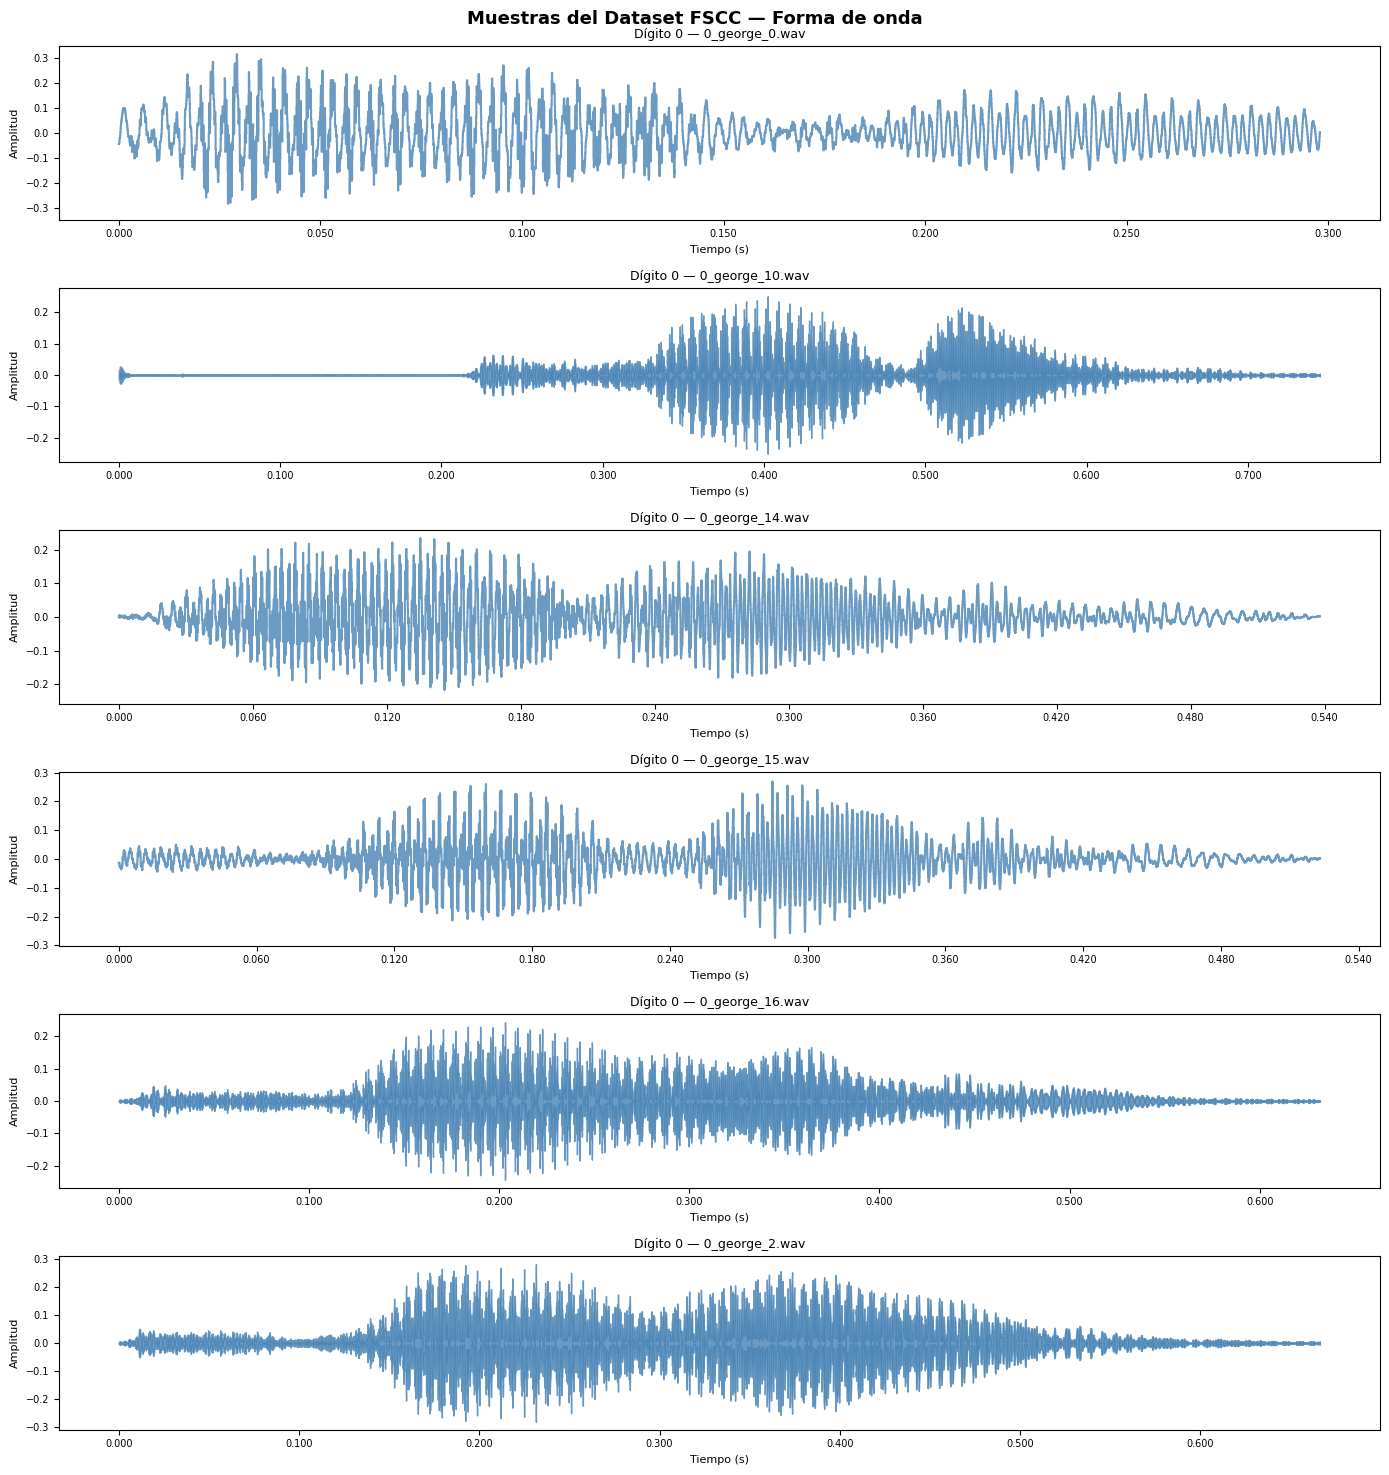


— Reproductores de audio —

#0 — Dígito 0  (0_george_0.wav)


#1 — Dígito 0  (0_george_10.wav)


#2 — Dígito 0  (0_george_14.wav)


#3 — Dígito 0  (0_george_15.wav)


#4 — Dígito 0  (0_george_16.wav)


#5 — Dígito 0  (0_george_2.wav)


In [4]:
N_SHOW = 6

fig, axes = plt.subplots(N_SHOW, 1, figsize=(14, N_SHOW * 2.5))
fig.suptitle("Muestras del Dataset FSCC — Forma de onda", fontsize=13, fontweight='bold')

for i, (y, ax) in enumerate(zip(signals[:N_SHOW], axes)):
    librosa.display.waveshow(y, sr=SR, ax=ax, color='steelblue', alpha=0.8)
    row = df_meta.iloc[i]
    ax.set_title(f"Dígito {row['digit']} — {row['filename']}", fontsize=9)
    ax.set_xlabel("Tiempo (s)", fontsize=8)
    ax.set_ylabel("Amplitud", fontsize=8)
    ax.tick_params(labelsize=7)

plt.tight_layout()
plt.show()

print("\n— Reproductores de audio —\n")
for i, y in enumerate(signals[:N_SHOW]):
    row = df_meta.iloc[i]
    print(f"#{i} — Dígito {row['digit']}  ({row['filename']})")
    display(ipd.Audio(y, rate=SR))


## **(3) STFT, magnitud y log-compresión**

  Batch 1 — frames acumulados: 12412
  Batch 2 — frames acumulados: 22744
  Batch 3 — frames acumulados: 32527
  Batch 4 — frames acumulados: 42468
  Batch 5 — frames acumulados: 52727
  Batch 6 — frames acumulados: 63964
  Batch 7 — frames acumulados: 75324
  Batch 8 — frames acumulados: 86832
  Batch 9 — frames acumulados: 97127
  Batch 10 — frames acumulados: 109651

Dataset de frames: (109651, 257)  (filas=frames, cols=bins de frecuencia)


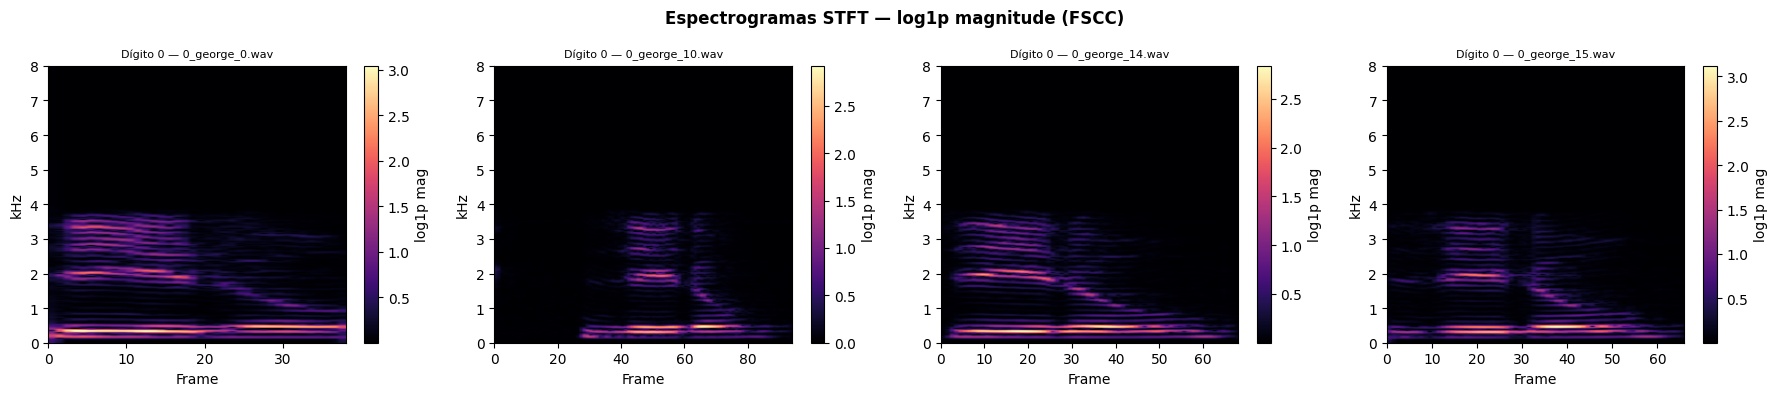

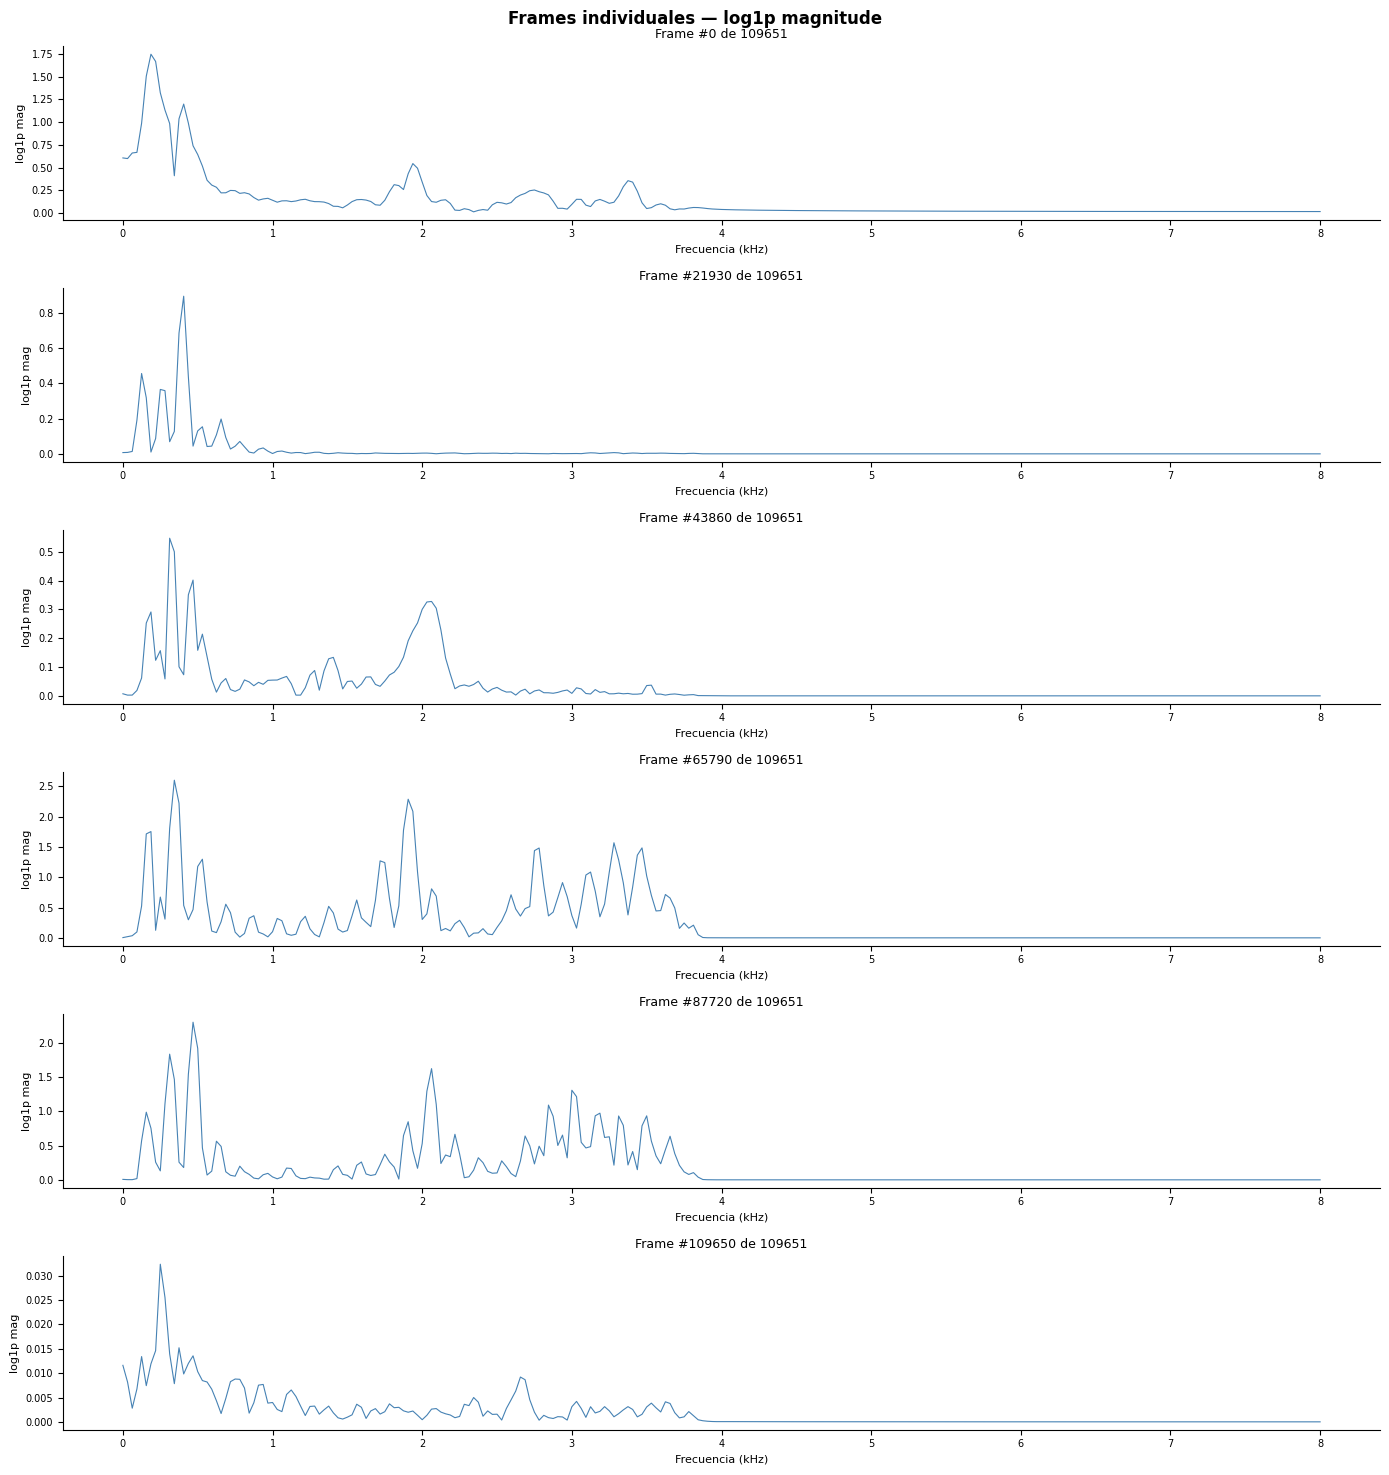

In [5]:
def signal_to_frames(y, n_fft=N_FFT, hop_length=HOP_LENGTH):
    #"""señal → (T, F) en espacio log1p."""    
    S = librosa.stft(y, n_fft=n_fft, hop_length=hop_length, window='hann')
    S = np.abs(S)
    S = np.log1p(S)
    return S.T.astype(np.float32)   # (T, F)


BATCH_FILES      = 200
MAX_FRAMES_TOTAL = 150_000

all_frames        = []
first_spectrogram = None
total_frames      = 0

for batch_start in range(0, len(signals), BATCH_FILES):
    batch        = signals[batch_start:batch_start + BATCH_FILES]
    batch_frames = []

    for y in batch:
        frames = signal_to_frames(y)
        batch_frames.append(frames)
        if first_spectrogram is None:
            first_spectrogram = frames

    chunk = np.vstack(batch_frames)
    all_frames.append(chunk)
    total_frames += chunk.shape[0]
    print(f"  Batch {batch_start//BATCH_FILES + 1} — frames acumulados: {total_frames}")

    if total_frames >= MAX_FRAMES_TOTAL:
        print("Cap de frames alcanzado.")
        break

X = np.vstack(all_frames)
if X.shape[0] > MAX_FRAMES_TOTAL:
    idx = np.random.choice(X.shape[0], MAX_FRAMES_TOTAL, replace=False)
    idx.sort()
    X = X[idx]

F = X.shape[1]
print(f"\nDataset de frames: {X.shape}  (filas=frames, cols=bins de frecuencia)")

# ── Espectrogramas de los 4 primeros audios ──────────────────────────────────
N_SHOW = 4
fig, axes = plt.subplots(1, N_SHOW, figsize=(18, 4))
fig.suptitle("Espectrogramas STFT — log1p magnitude (FSCC)", fontsize=12, fontweight='bold')

for i, ax in enumerate(axes):
    frames = signal_to_frames(signals[i])
    freqs  = librosa.fft_frequencies(sr=SR, n_fft=N_FFT)
    img = ax.imshow(
        frames.T,
        aspect='auto',
        origin='lower',
        cmap='magma',
        extent=[0, frames.shape[0], freqs[0]/1000, freqs[-1]/1000]
    )
    row = df_meta.iloc[i]
    ax.set_title(f"Dígito {row['digit']} — {row['filename']}", fontsize=8)
    ax.set_xlabel("Frame")
    ax.set_ylabel("kHz")
    plt.colorbar(img, ax=ax, label="log1p mag")

plt.tight_layout()
plt.show()

# ── 6 frames individuales ────────────────────────────────────────────────────
N_SHOW  = 6
indices = np.linspace(0, len(X) - 1, N_SHOW, dtype=int)
freqs   = librosa.fft_frequencies(sr=SR, n_fft=N_FFT)

fig, axes = plt.subplots(N_SHOW, 1, figsize=(14, N_SHOW * 2.5))
fig.suptitle("Frames individuales — log1p magnitude", fontsize=12, fontweight='bold')

for ax, idx in zip(axes, indices):
    ax.plot(freqs / 1000, X[idx], color='steelblue', lw=0.8)
    ax.set_title(f"Frame #{idx} de {len(X)}", fontsize=9)
    ax.set_xlabel("Frecuencia (kHz)", fontsize=8)
    ax.set_ylabel("log1p mag", fontsize=8)
    ax.tick_params(labelsize=7)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()


## **(4) Aprendizaje del diccionario**

In [6]:
MAX_TRAIN_FRAMES = 50_000
if X.shape[0] > MAX_TRAIN_FRAMES:
    idx     = np.random.choice(X.shape[0], MAX_TRAIN_FRAMES, replace=False)
    X_train = X[idx]
else:
    X_train = X

dict_learner = MiniBatchDictionaryLearning(
    n_components=N_COMPONENTS,
    alpha=ALPHA,
    batch_size=BATCH_SIZE,
    max_iter=MAX_ITER,
    transform_algorithm='lasso_lars',
    fit_algorithm='cd',
    n_jobs=-1,
    random_state=42,
    verbose=0
)

print(f"Entrenando con {X_train.shape[0]} frames — shape {X_train.shape}...")
dict_learner.fit(X_train)

D = dict_learner.components_   # (N_COMPONENTS, F)
print(f"\nDiccionario D: {D.shape}")


Entrenando con 50000 frames — shape (50000, 257)...

Diccionario D: (512, 257)


## **(5) Visualización y reproducción de 8 átomos aleatorios**

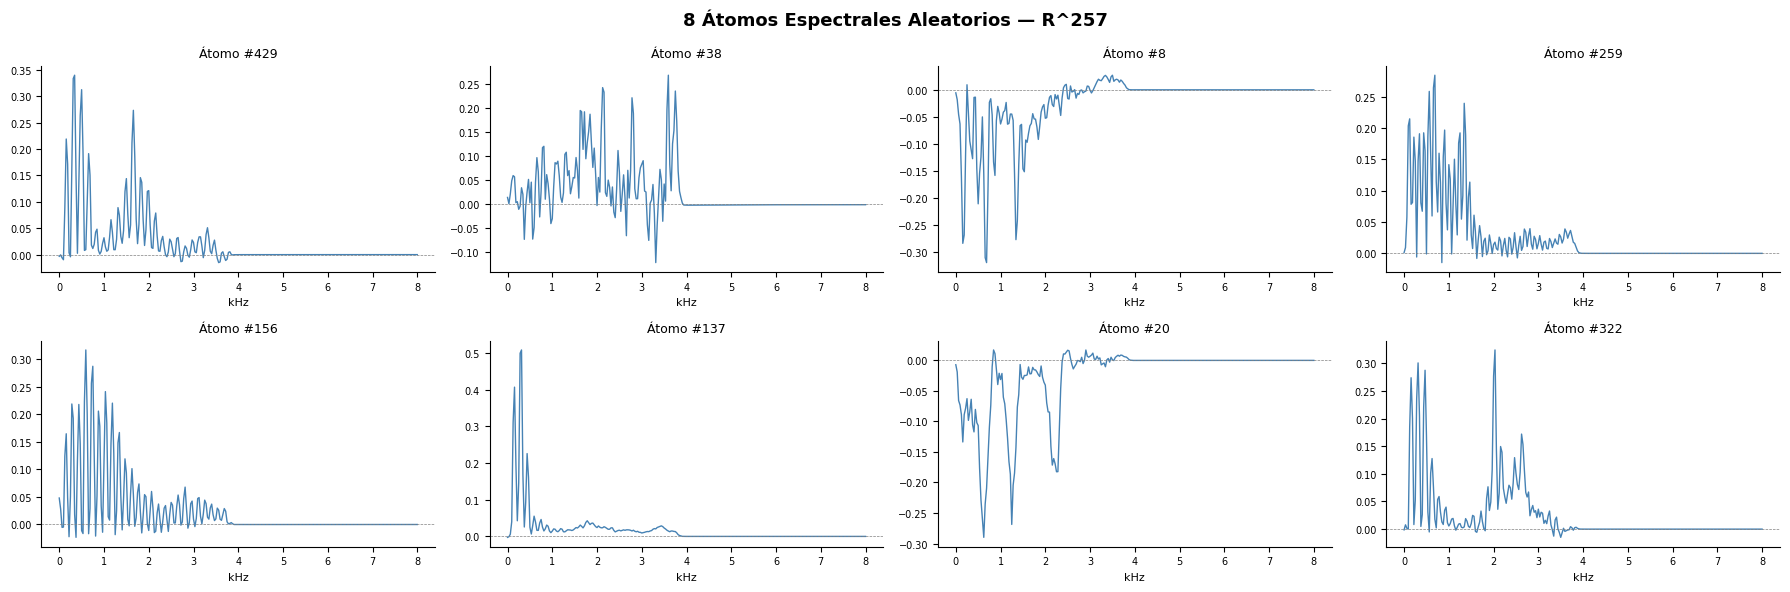


— Reproducción de átomos aleatorios —

Átomo #429


Átomo #38


Átomo #8


Átomo #259


Átomo #156


Átomo #137


Átomo #20


Átomo #322


In [7]:
def frames_to_audio(frames, n_iter=256, sr=SR, hop_length=HOP_LENGTH, n_fft=N_FFT):
    #"""frames (T, F) en log1p → señal de audio via Griffin-Lim."""    
    mag = np.expm1(np.maximum(frames, 0))   # (T, F)
    mag = mag.T                              # (F, T)
    y   = librosa.griffinlim(
        mag, n_iter=n_iter, hop_length=hop_length,
        win_length=n_fft, window='hann'
    )
    y = y / (np.max(np.abs(y)) + 1e-8)
    return y


def atom_to_audio(atom, duration=1.0, sr=SR, n_iter=256, hop_length=HOP_LENGTH, n_fft=N_FFT):
    #"""Átomo (perfil espectral log1p) → audio via Griffin-Lim."""   
    mag      = np.expm1(np.maximum(atom, 0))
    n_frames = int(duration * sr / hop_length)
    S_mag    = np.tile(mag, (n_frames, 1)).T    # (F, T)
    y        = librosa.griffinlim(
        S_mag, n_iter=n_iter, hop_length=hop_length,
        win_length=n_fft, window='hann'
    )
    y = y / (np.max(np.abs(y)) + 1e-8)
    return y


freqs    = librosa.fft_frequencies(sr=SR, n_fft=N_FFT)
rng      = np.random.default_rng(0)
rand_idx = rng.choice(N_COMPONENTS, size=8, replace=False)

fig, axes = plt.subplots(2, 4, figsize=(18, 6))
fig.suptitle(f"8 Átomos Espectrales Aleatorios — R^{len(freqs)}", fontsize=13, fontweight='bold')

for ax, k in zip(axes.flat, rand_idx):
    atom = D[k]
    ax.plot(freqs / 1000, atom, lw=1.0, color='steelblue')
    ax.set_title(f"Átomo #{k}", fontsize=9)
    ax.set_xlabel("kHz", fontsize=8)
    ax.axhline(0, color='gray', lw=0.5, ls='--')
    ax.tick_params(labelsize=7)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

print("\n— Reproducción de átomos aleatorios —\n")
for k in rand_idx:
    y_atom = atom_to_audio(D[k])
    if np.any(np.isnan(y_atom)) or np.max(np.abs(y_atom)) < 1e-8:
        print(f"Átomo #{k} — silencio")
        display(ipd.Audio(np.zeros(SR), rate=SR))
    else:
        print(f"Átomo #{k}")
        display(ipd.Audio(y_atom, rate=SR))


## **(6) Átomos más usados**

Codificamos todos los frames de entrenamiento con `SparseCoder` y contamos cuántas
veces cada átomo tiene un coeficiente activo (|α| > umbral). Los átomos más
frecuentes son los patrones espectrales más recurrentes en los dígitos hablados.


  Bloque 10/10 — atoms contados...
Top 8 átomos más usados:
  Rank 1: Átomo # 163  — usado en 1942 frames
  Rank 2: Átomo #   0  — usado en 1922 frames
  Rank 3: Átomo # 373  — usado en 1743 frames
  Rank 4: Átomo # 460  — usado en 1607 frames
  Rank 5: Átomo # 197  — usado en 1472 frames
  Rank 6: Átomo # 227  — usado en 1423 frames
  Rank 7: Átomo # 137  — usado en 1396 frames
  Rank 8: Átomo # 505  — usado en 1359 frames


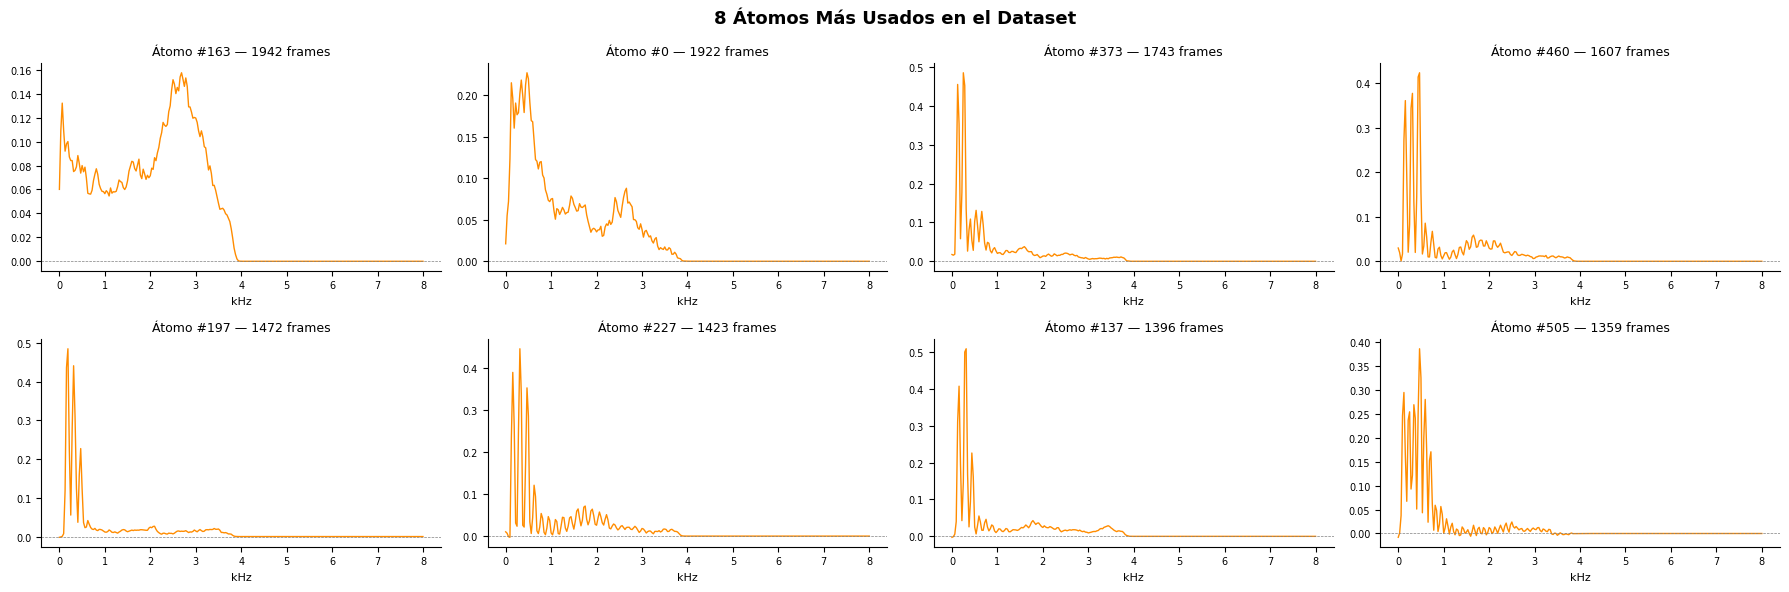


— Reproducción de los átomos más usados —

Átomo #163 (usado en 1942 frames)


Átomo #0 (usado en 1922 frames)


Átomo #373 (usado en 1743 frames)


Átomo #460 (usado en 1607 frames)


Átomo #197 (usado en 1472 frames)


Átomo #227 (usado en 1423 frames)


Átomo #137 (usado en 1396 frames)


Átomo #505 (usado en 1359 frames)


In [8]:
coder_full = SparseCoder(
    dictionary=D,
    transform_algorithm='lasso_lars',
    transform_alpha=ALPHA
)

# Codificar en bloques para no saturar RAM
CHUNK = 5000
atom_counts = np.zeros(N_COMPONENTS, dtype=np.int64)

for start in range(0, X_train.shape[0], CHUNK):
    chunk = X_train[start:start + CHUNK]
    A_chunk = coder_full.transform(chunk)
    atom_counts += np.sum(np.abs(A_chunk) > THRESHOLD, axis=0)
    print(f"  Bloque {start//CHUNK + 1}/{-(-X_train.shape[0]//CHUNK)} — atoms contados...", end='\r')

print()
top8 = np.argsort(atom_counts)[::-1][:8]

print("Top 8 átomos más usados:")
for rank, k in enumerate(top8):
    print(f"  Rank {rank+1}: Átomo #{k:4d}  — usado en {atom_counts[k]} frames")

fig, axes = plt.subplots(2, 4, figsize=(18, 6))
fig.suptitle("8 Átomos Más Usados en el Dataset", fontsize=13, fontweight='bold')

for ax, k in zip(axes.flat, top8):
    ax.plot(freqs / 1000, D[k], lw=1.0, color='darkorange')
    ax.set_title(f"Átomo #{k} — {atom_counts[k]} frames", fontsize=9)
    ax.set_xlabel("kHz", fontsize=8)
    ax.axhline(0, color='gray', lw=0.5, ls='--')
    ax.tick_params(labelsize=7)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

print("\n— Reproducción de los átomos más usados —\n")
for k in top8:
    y_atom = atom_to_audio(D[k])
    print(f"Átomo #{k} (usado en {atom_counts[k]} frames)")
    display(ipd.Audio(y_atom, rate=SR))


## **(7) Reconstrucción de 4 audios con SparseCoder**


Audio #0 — Dígito 0  (0_george_0.wav)
  ||X - AD||_F / ||X||_F  : 0.2027  (20.27%)
  Sparsity (||A||_0/|A|)  : 0.9752  (97.52% ceros)
  Átomos únicos activos   : 152 / 512


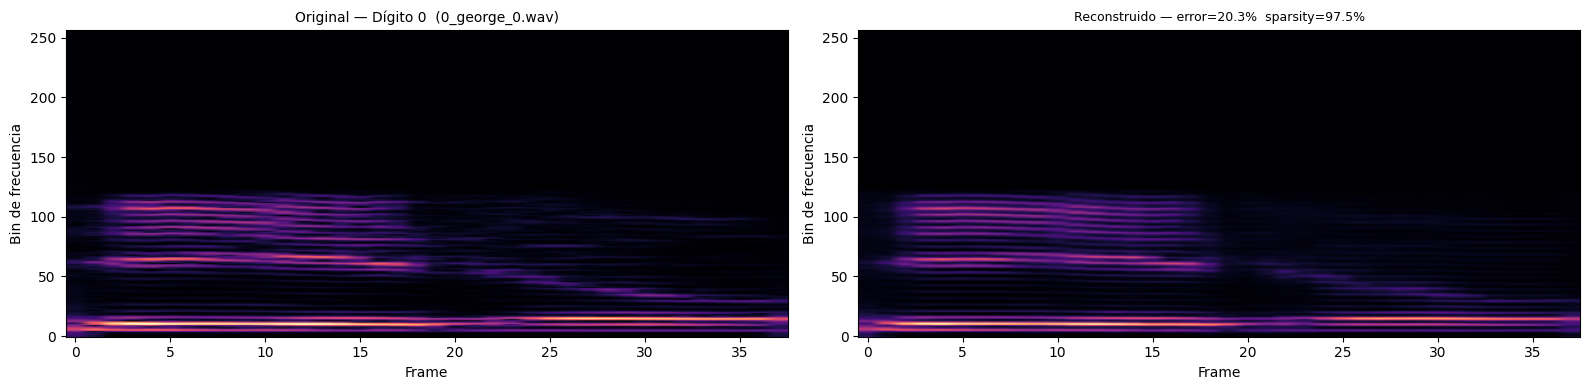

Audio original #0 (dígito 0):


Audio reconstruido #0:



Audio #1 — Dígito 0  (0_george_10.wav)
  ||X - AD||_F / ||X||_F  : 0.2221  (22.21%)
  Sparsity (||A||_0/|A|)  : 0.9893  (98.93% ceros)
  Átomos únicos activos   : 108 / 512


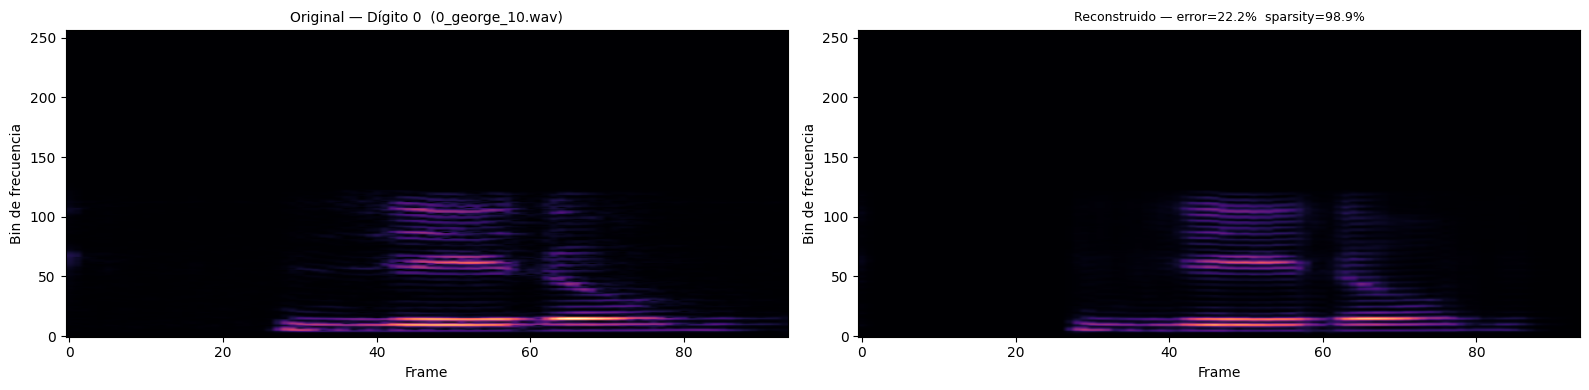

Audio original #1 (dígito 0):


Audio reconstruido #1:



Audio #2 — Dígito 0  (0_george_14.wav)
  ||X - AD||_F / ||X||_F  : 0.2174  (21.74%)
  Sparsity (||A||_0/|A|)  : 0.9848  (98.48% ceros)
  Átomos únicos activos   : 109 / 512


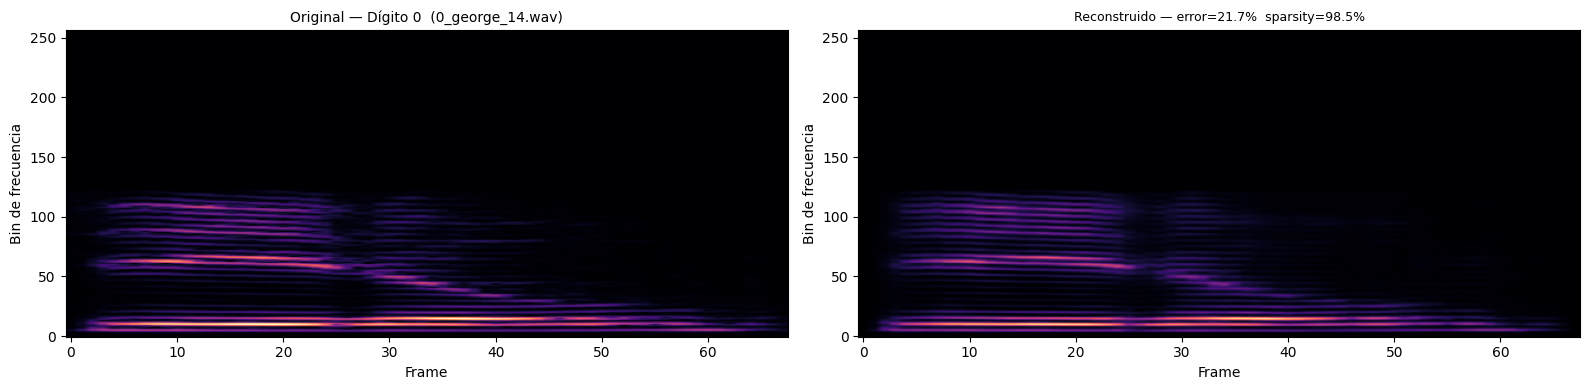

Audio original #2 (dígito 0):


Audio reconstruido #2:



Audio #3 — Dígito 0  (0_george_15.wav)
  ||X - AD||_F / ||X||_F  : 0.2083  (20.83%)
  Sparsity (||A||_0/|A|)  : 0.9827  (98.27% ceros)
  Átomos únicos activos   : 132 / 512


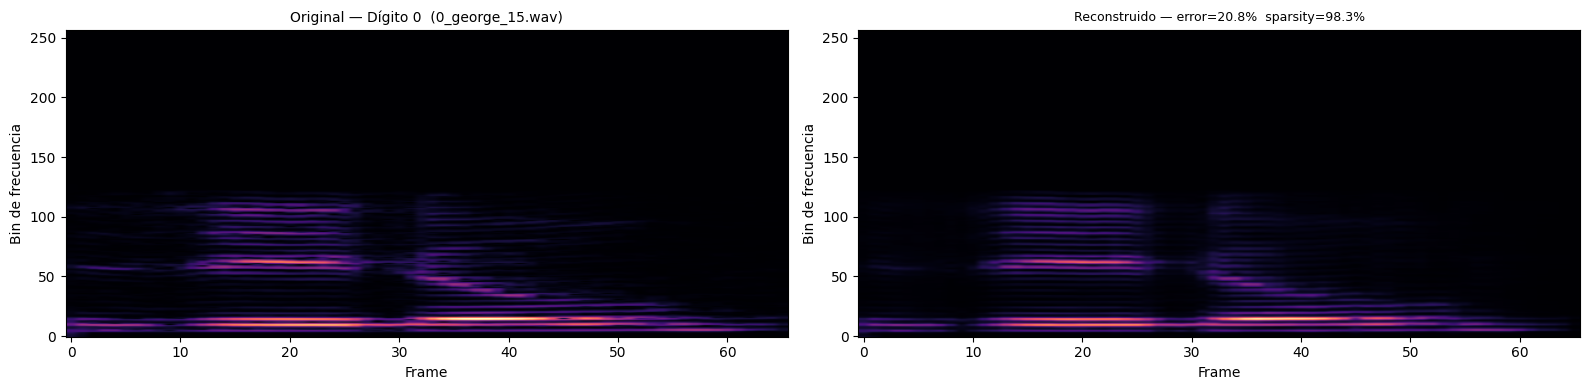

Audio original #3 (dígito 0):


Audio reconstruido #3:


In [9]:
N_RECONSTRUCT = 4

coder = SparseCoder(
    dictionary=D,
    transform_algorithm='lasso_lars',
    transform_alpha=ALPHA
)

for IDX in range(N_RECONSTRUCT):
    y_original  = signals[IDX]
    row         = df_meta.iloc[IDX]

    frames_orig = signal_to_frames(y_original)
    A_rec       = coder.transform(frames_orig)
    frames_rec  = A_rec @ D

    error_rel = np.linalg.norm(frames_orig - frames_rec) / (np.linalg.norm(frames_orig) + 1e-8)
    nnz       = np.sum(np.abs(A_rec) > THRESHOLD)
    sparsity  = 1 - (nnz / A_rec.size)
    atoms_active = np.sum(np.any(np.abs(A_rec) > THRESHOLD, axis=0))

    print(f"\n{'='*55}")
    print(f"Audio #{IDX} — Dígito {row['digit']}  ({row['filename']})")
    print(f"  ||X - AD||_F / ||X||_F  : {error_rel:.4f}  ({error_rel*100:.2f}%)")
    print(f"  Sparsity (||A||_0/|A|)  : {sparsity:.4f}  ({sparsity*100:.2f}% ceros)")
    print(f"  Átomos únicos activos   : {atoms_active} / {N_COMPONENTS}")
    print(f"{'='*55}")

    fig, axes = plt.subplots(1, 2, figsize=(16, 4))
    vmin, vmax = frames_orig.min(), frames_orig.max()

    axes[0].imshow(frames_orig.T, aspect='auto', origin='lower', cmap='magma', vmin=vmin, vmax=vmax)
    axes[0].set_title(f"Original — Dígito {row['digit']}  ({row['filename']})", fontsize=10)
    axes[0].set_xlabel("Frame")
    axes[0].set_ylabel("Bin de frecuencia")

    axes[1].imshow(frames_rec.T, aspect='auto', origin='lower', cmap='magma', vmin=vmin, vmax=vmax)
    axes[1].set_title(
        f"Reconstruido — error={error_rel*100:.1f}%  sparsity={sparsity*100:.1f}%",
        fontsize=9
    )
    axes[1].set_xlabel("Frame")
    axes[1].set_ylabel("Bin de frecuencia")

    plt.tight_layout()
    plt.show()

    print(f"Audio original #{IDX} (dígito {row['digit']}):")
    display(ipd.Audio(y_original, rate=SR))

    y_rec = frames_to_audio(frames_rec, n_iter=256)
    print(f"Audio reconstruido #{IDX}:")
    display(ipd.Audio(y_rec, rate=SR))
